In [1]:
%cd ..

/home/dev/workspace


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=''", "+experiment=marionette_captcha",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

E0624 20:00:44.304395  158174 ptx_compiler_helpers.cc:157] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
Best ckpt not found! Using current weights for testing...
E0624 20:01:40.022607  158159 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0624 20:02:10.633310  158159 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [5]:
metrics

{'loss': np.float32(643484.2),
 'log_w': np.float32(-603266.4),
 'nll': np.float32(18247.955),
 'kl': np.float32(604.1194),
 'log_Z': np.float32(-52762.664),
 'ess': np.float32(0.0625)}

In [6]:
for data, target in objects['datamodule'].valid_dataloader():
    metrics, predictions = objects['learner'](data, stage="valid")
    break

/home/dev/workspace/src/inference/tracer.py:101: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.53017455..1.0000004].


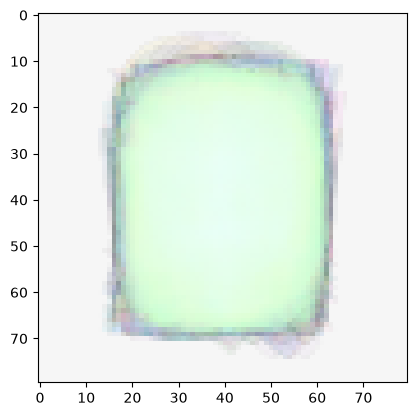

In [7]:
plt.imshow(predictions["obs"]["ev"].mean(axis=0)[0])

In [8]:
# plt.imshow(predictions["salience_map"]["ev"].mean(axis=0)[0])

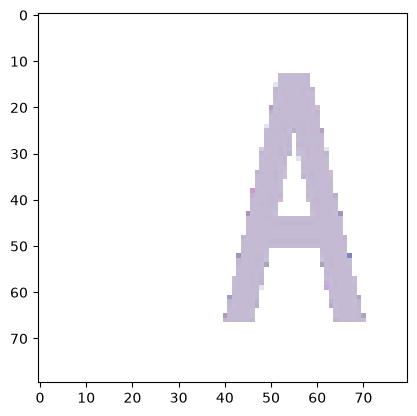

In [9]:
plt.imshow(data[0])